In [ ]:
print("Installing factor_analyzer package...")
!pip install factor_analyzer
print("factor_analyzer package installed.")

Installing factor_analyzer package...
factor_analyzer package installed.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

import statsmodels.api as sm

print("All necessary libraries imported successfully.")

All necessary libraries imported successfully.


In [ ]:
# ------------------------------------------------------------
# 1.1 LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("/content/Customer_Profiling.csv")

# Quick look
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
print("Checking for null values:")
print(df.isnull().sum())
print(f"\nTotal null values: {df.isnull().sum().sum()}")

print("\nChecking for duplicate rows:")
print(f"Total duplicate rows: {df.duplicated().sum()}")

Checking for null values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Total null values: 24

Checking for duplicate rows:
Total duplicate rows: 0


In [ ]:
# Impute Income with median (skewed)
df['Income'] = df['Income'].fillna(df['Income'].median())

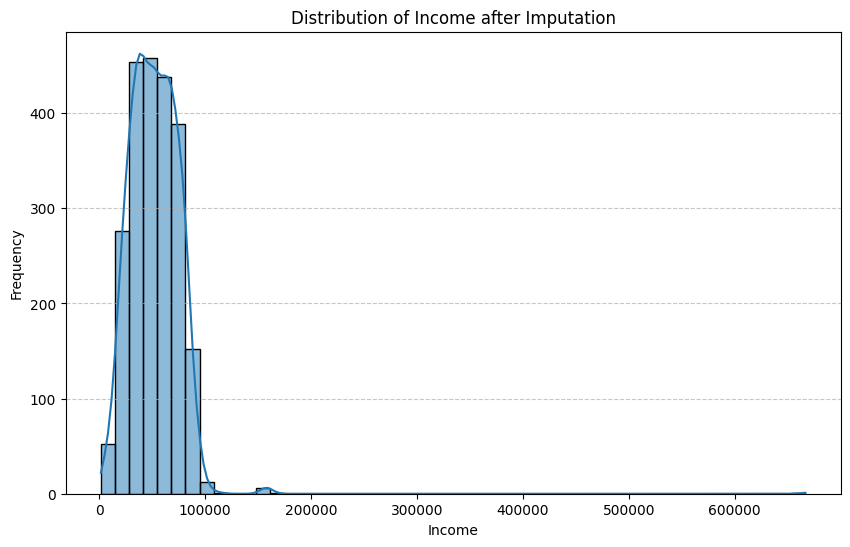

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], kde=True, bins=50)
plt.title('Distribution of Income after Imputation')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This plot shows the distribution of the 'Income' column after missing values were filled with the median. The histogram bars represent the frequency of different income ranges, and the KDE line provides a smoothed representation of the distribution.

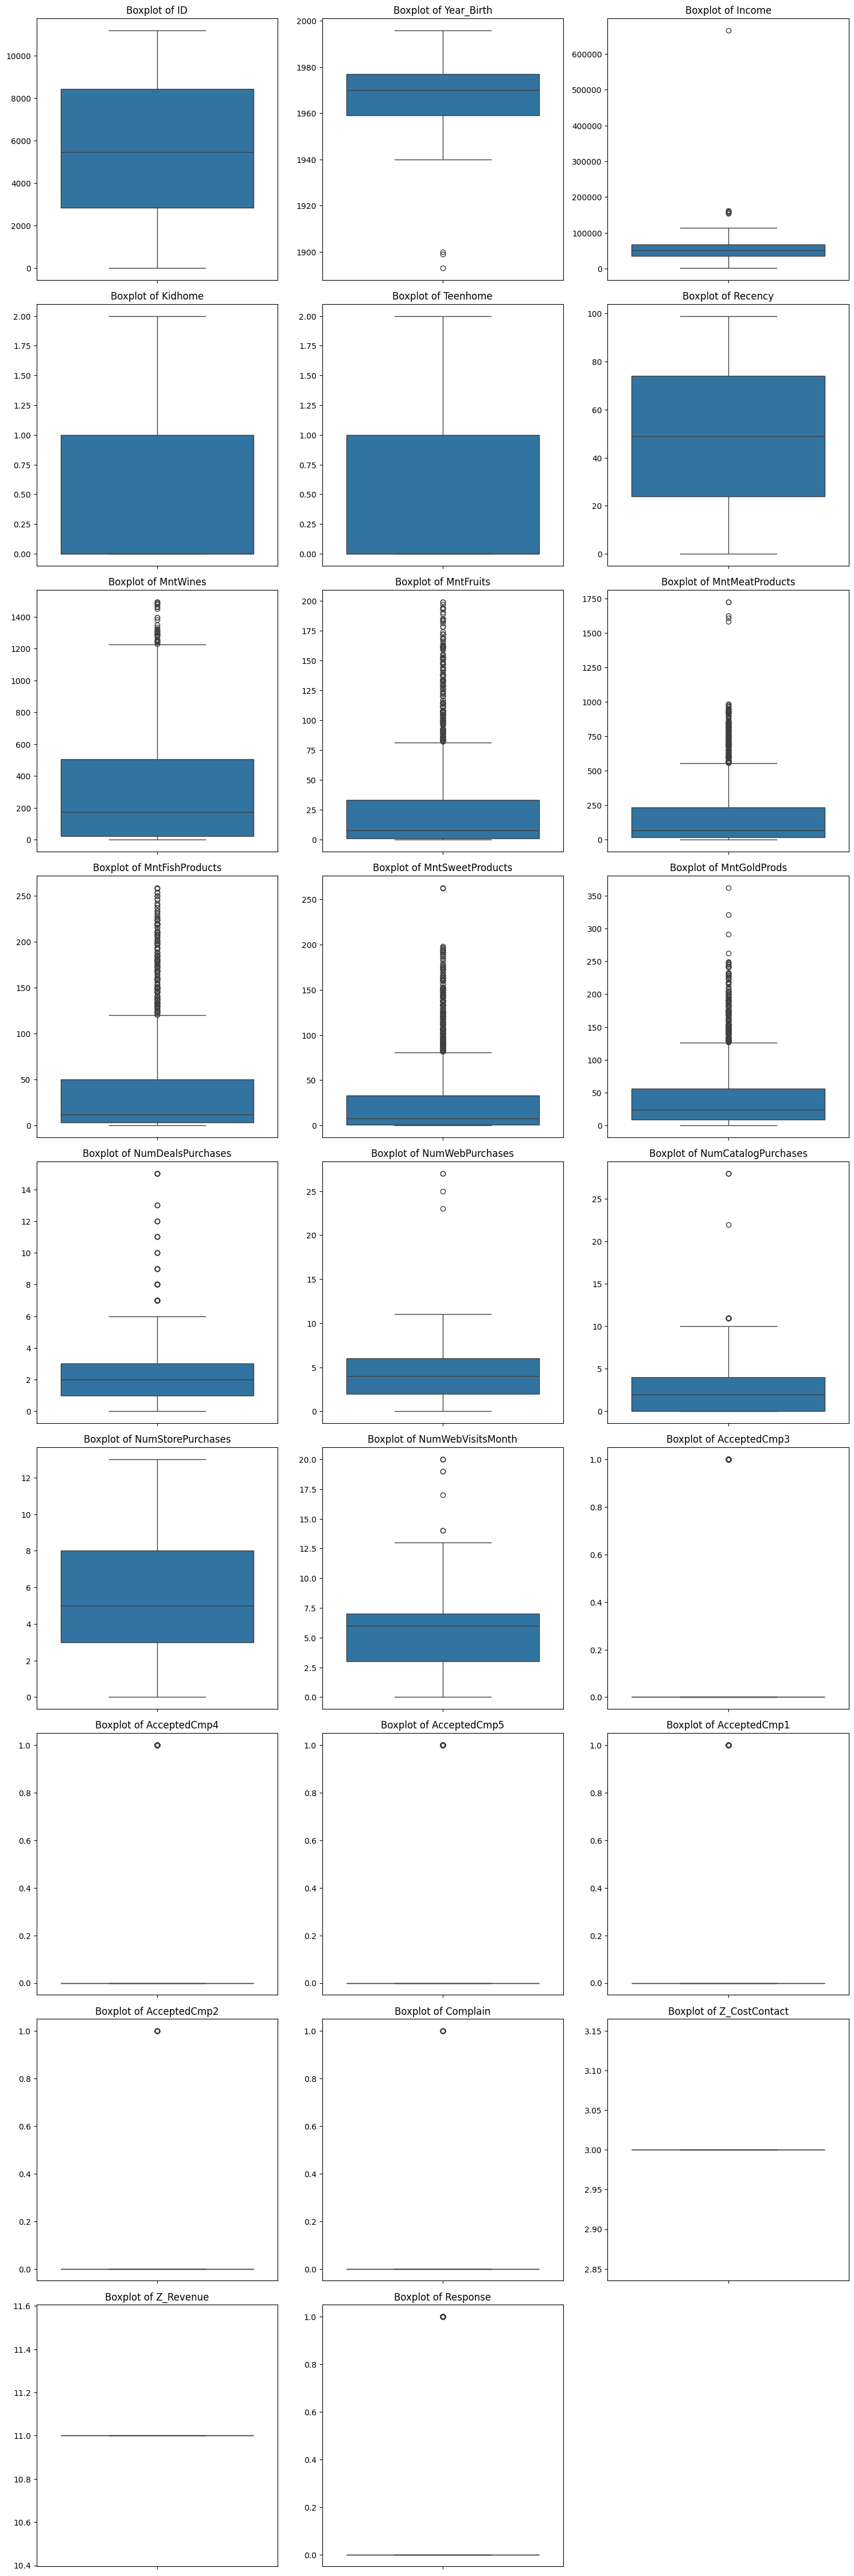

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for boxplots
numerical_cols = df.select_dtypes(include=np.number).columns

# Set up the figure size to accommodate multiple plots
# Adjust the grid layout based on the number of numerical columns
num_plots = len(numerical_cols)
num_cols_per_row = 3
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row # Ceiling division

plt.figure(figsize=(15, 5 * num_rows)) # Adjust figure height dynamically

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols_per_row, i + 1) # Arrange plots in a grid
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter

plt.tight_layout()
plt.show()

In [ ]:
columns_for_outlier_check = [
    'Income',
    'Recency',
    'MntWines',
    'NumWebVisitsMonth',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'Year_Birth'
]

print("--- IQR Outlier Analysis ---")
for col in columns_for_outlier_check:
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"\nColumn: {col}")
        print(f"  Q1: {Q1:.2f}")
        print(f"  Q3: {Q3:.2f}")
        print(f"  IQR: {IQR:.2f}")
        print(f"  Lower Bound: {lower_bound:.2f}")
        print(f"  Upper Bound: {upper_bound:.2f}")
        print(f"  Number of outliers: {len(outliers)}")
        if len(outliers) > 0:
            print(f"  Outliers percentage: {(len(outliers) / len(df)) * 100:.2f}%")
    else:
        print(f"\nColumn '{col}' is not numeric or not found in the DataFrame.")
print("----------------------------")

--- IQR Outlier Analysis ---

Column: Income
  Q1: 35538.75
  Q3: 68289.75
  IQR: 32751.00
  Lower Bound: -13587.75
  Upper Bound: 117416.25
  Number of outliers: 8
  Outliers percentage: 0.36%

Column: Recency
  Q1: 24.00
  Q3: 74.00
  IQR: 50.00
  Lower Bound: -51.00
  Upper Bound: 149.00
  Number of outliers: 0

Column: MntWines
  Q1: 23.75
  Q3: 504.25
  IQR: 480.50
  Lower Bound: -697.00
  Upper Bound: 1225.00
  Number of outliers: 35
  Outliers percentage: 1.56%

Column: NumWebVisitsMonth
  Q1: 3.00
  Q3: 7.00
  IQR: 4.00
  Lower Bound: -3.00
  Upper Bound: 13.00
  Number of outliers: 8
  Outliers percentage: 0.36%

Column: MntFruits
  Q1: 1.00
  Q3: 33.00
  IQR: 32.00
  Lower Bound: -47.00
  Upper Bound: 81.00
  Number of outliers: 227
  Outliers percentage: 10.13%

Column: MntMeatProducts
  Q1: 16.00
  Q3: 232.00
  IQR: 216.00
  Lower Bound: -308.00
  Upper Bound: 556.00
  Number of outliers: 175
  Outliers percentage: 7.81%

Column: MntFishProducts
  Q1: 3.00
  Q3: 50.00
  IQR

In [ ]:
# Apply IQR-based capping for outliers
print("--- Applying IQR Outlier Capping ---")
for col in columns_for_outlier_check:
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values that are below the lower bound or above the upper bound
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        print(f"Capped outliers for column: {col}")
    else:
        print(f"Skipping capping for column '{col}' (not numeric or not found).")
print("------------------------------------")

--- Applying IQR Outlier Capping ---
Capped outliers for column: Income
Capped outliers for column: Recency
Capped outliers for column: MntWines
Capped outliers for column: NumWebVisitsMonth
Capped outliers for column: MntFruits
Capped outliers for column: MntMeatProducts
Capped outliers for column: MntFishProducts
Capped outliers for column: MntSweetProducts
Capped outliers for column: MntGoldProds
Capped outliers for column: NumDealsPurchases
Capped outliers for column: NumWebPurchases
Capped outliers for column: NumCatalogPurchases
Capped outliers for column: NumStorePurchases
Capped outliers for column: Year_Birth
------------------------------------


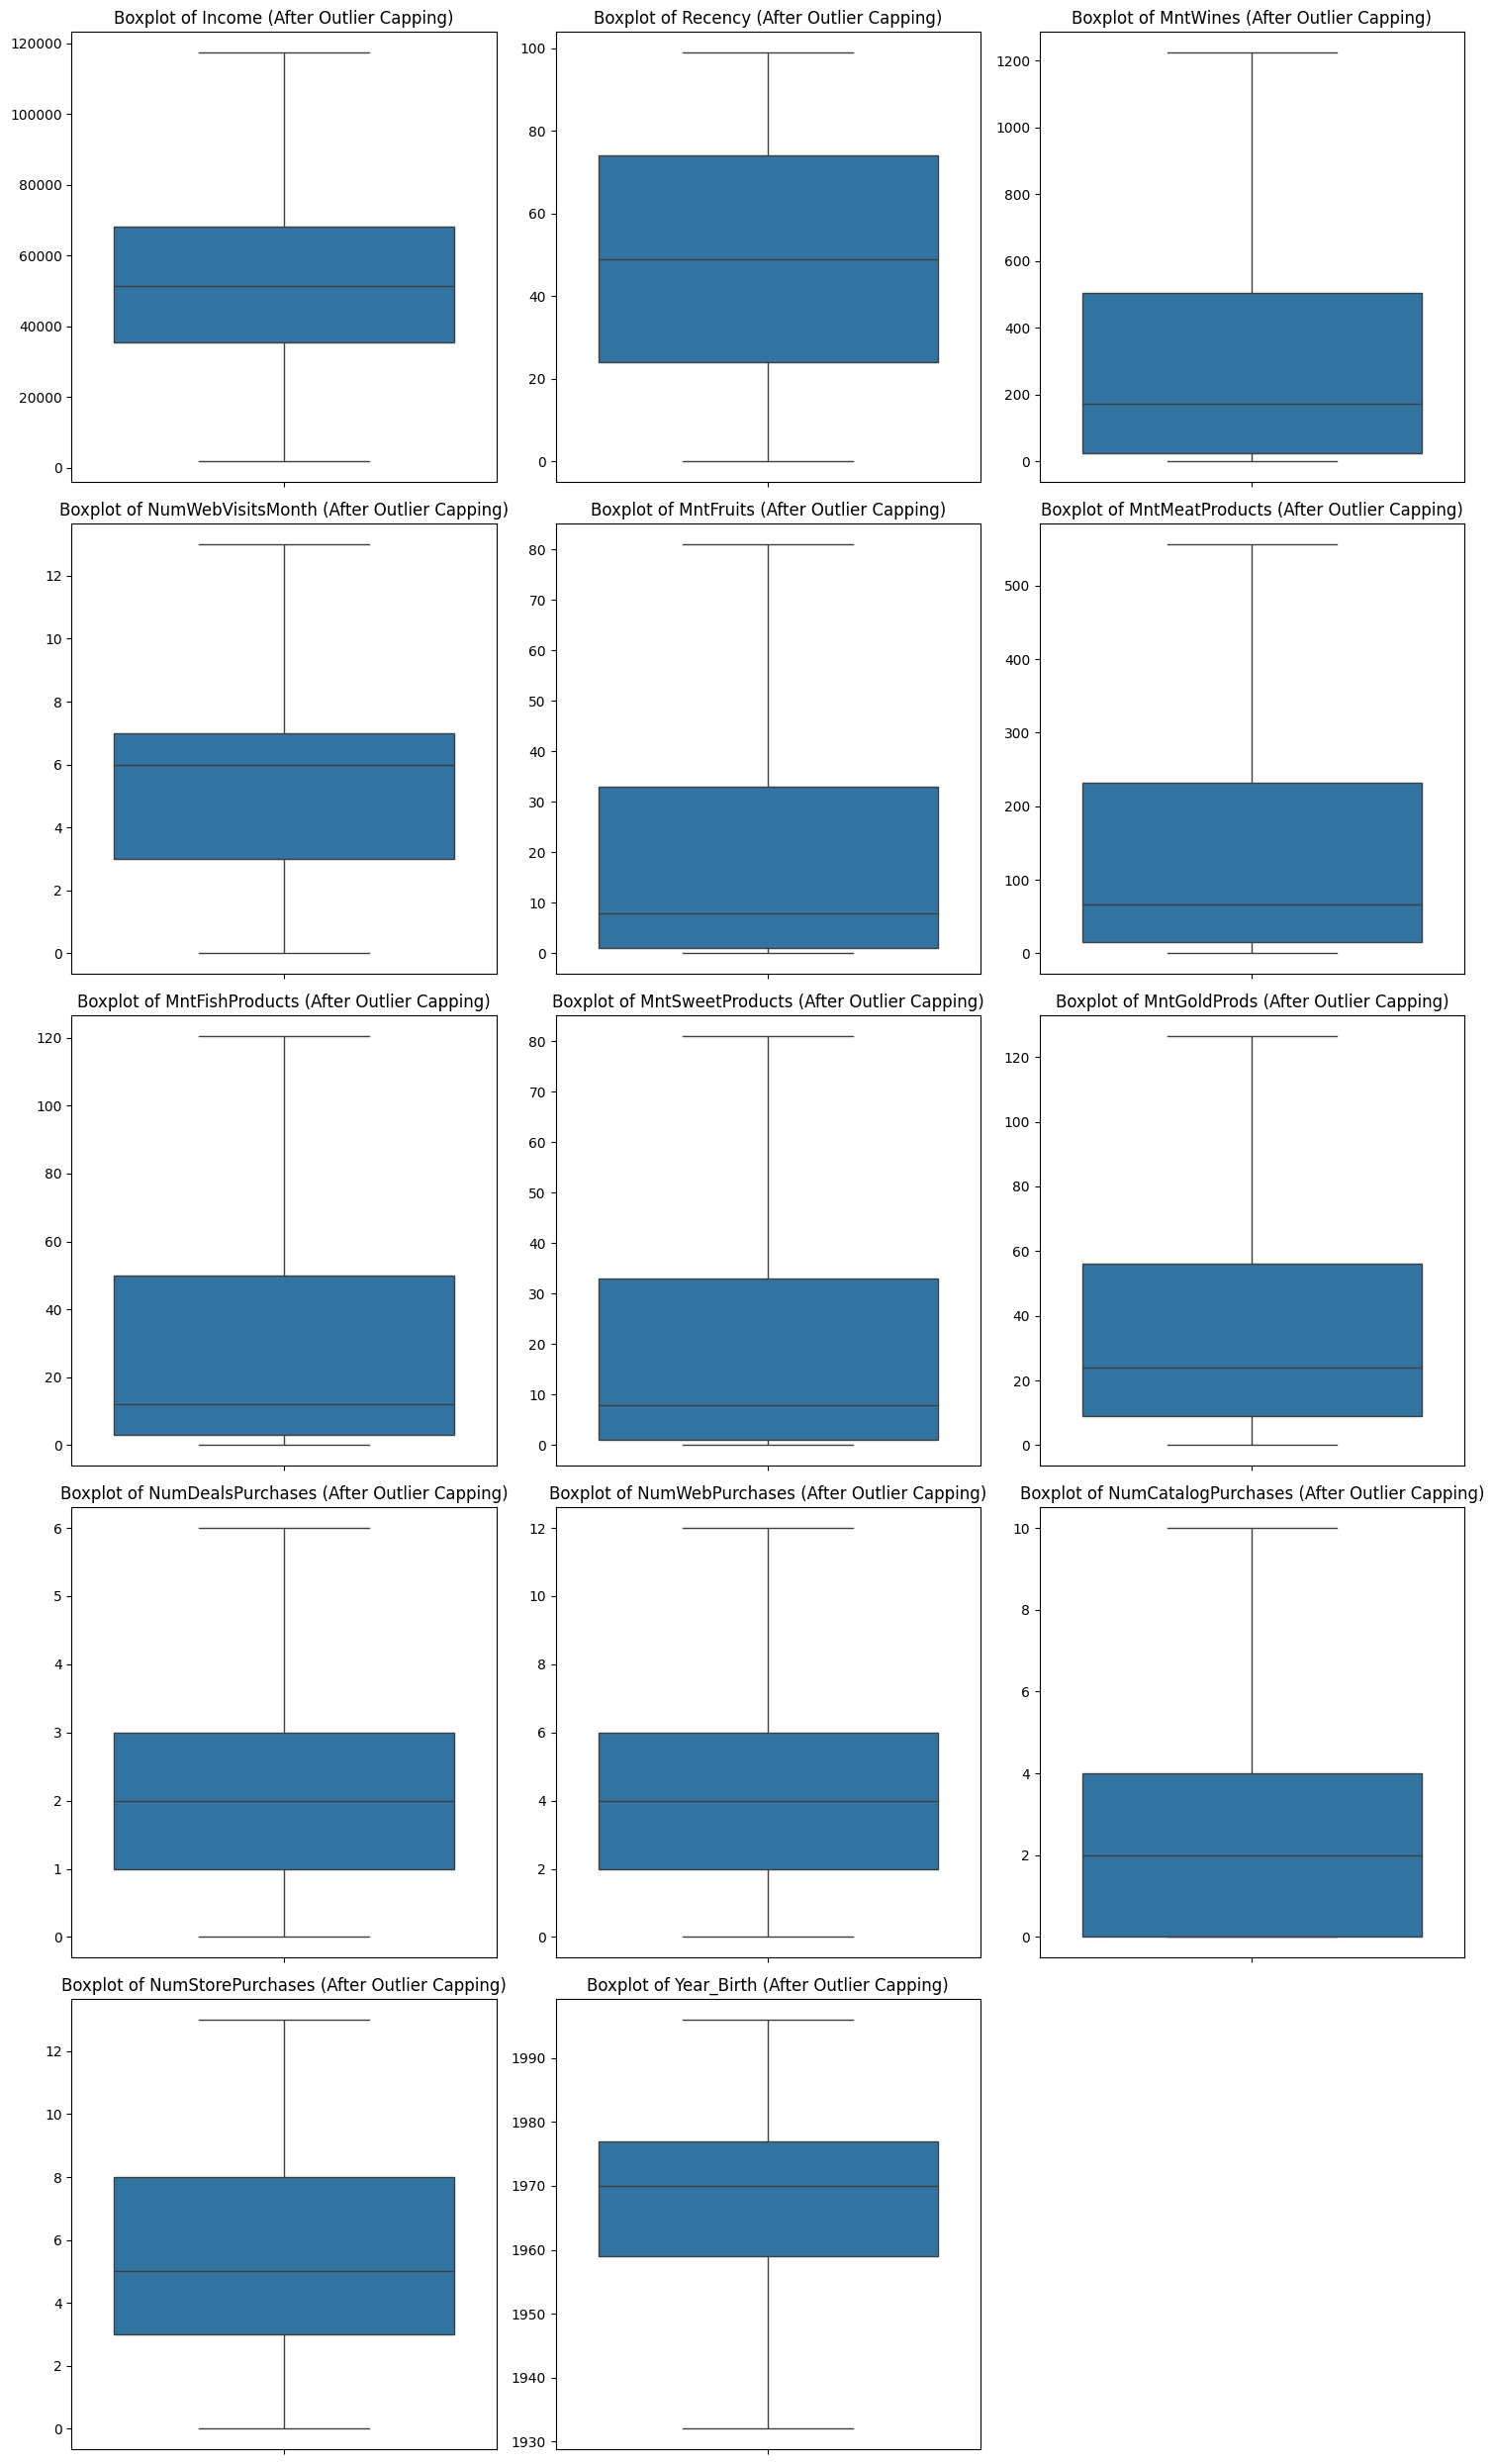

In [ ]:
# Plot boxplots again for the columns after outlier capping
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to only the columns for which we checked and capped outliers
num_plots_after_capping = len(columns_for_outlier_check)
num_cols_per_row = 3
num_rows_after_capping = (num_plots_after_capping + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(15, 5 * num_rows_after_capping))

for i, col in enumerate(columns_for_outlier_check):
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        plt.subplot(num_rows_after_capping, num_cols_per_row, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col} (After Outlier Capping)')
        plt.ylabel('')
    else:
        print(f"Could not plot boxplot for '{col}' (not numeric or not found).")

plt.tight_layout()
plt.show()

These boxplots show the distributions of the specified columns after outliers have been treated using the IQR-based capping method. Values below the lower bound and above the upper bound are now limited to these bounds, making the distributions appear more contained.

In [ ]:
# Convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")

# Take "current date" as max date in data (or use today's date)
current_date = df['Dt_Customer'].max()

# Customer tenure in days & months
df['Customer_Tenure_Days'] = (current_date - df['Dt_Customer']).dt.days
df['Customer_Tenure_Months'] = df['Customer_Tenure_Days'] / 30.0

# Enrollment year
df['Enrollment_Year'] = df['Dt_Customer'].dt.year

In [ ]:
# Convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Take "current date" as max date in data (or use today's date)
current_date = df['Dt_Customer'].max()

# Customer tenure in days & months
df['Customer_Tenure_Days'] = (current_date - df['Dt_Customer']).dt.days
df['Customer_Tenure_Months'] = df['Customer_Tenure_Days'] / 30.0

# Enrollment year
df['Enrollment_Year'] = df['Dt_Customer'].dt.year


In [ ]:
# ------------------------------------------------------------
# 2.1 CUSTOMER BEHAVIOR FEATURES
# ------------------------------------------------------------
spend_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

df['Total_Expenditure'] = df[spend_cols].sum(axis=1)

# Avoid division by zero
df['Customer_Tenure_Months'] = df['Customer_Tenure_Months'].replace(0, np.nan)
df['Average_Monthly_Spend'] = df['Total_Expenditure'] / df['Customer_Tenure_Months']

# Dependency ratio = (Kids + Teens) / Adults
df['Adults'] = 2  # assumption: 2 adults per household; change if you have better info
df['Dependency_Ratio'] = (df['Kidhome'] + df['Teenhome']) / df['Adults']

# Engagement score
df['Engagement_Score'] = (df['NumWebVisitsMonth'] * 0.4) + (df['NumStorePurchases'] * 0.6)


In [ ]:
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
            'AcceptedCmp4', 'AcceptedCmp5', 'Response']

df['Campaign_Response'] = (df[cmp_cols].sum(axis=1) > 0).astype(int)


In [ ]:
# Example: one-hot encode Education & Marital_Status
cat_cols = ['Education', 'Marital_Status']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [ ]:
fa_vars = [
    'Income', 'Total_Expenditure', 'Average_Monthly_Spend',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'Recency', 'Customer_Tenure_Days', 'Dependency_Ratio',
    'Engagement_Score', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases',
    'NumDealsPurchases', 'NumWebVisitsMonth'
]

X = df[fa_vars].dropna().copy()


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=fa_vars)


In [ ]:
corr_matrix = X_scaled_df.corr()
corr_matrix.round(2)


,Income,Total_Expenditure,Average_Monthly_Spend,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Recency,Customer_Tenure_Days,Dependency_Ratio,Engagement_Score,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth
Income,1.00,0.80,0.14,0.71,0.57,0.74,0.58,0.58,0.44,0.00,-0.02,-0.35,0.37,0.49,0.72,0.65,-0.15,-0.65
Total_Expenditure,0.80,1.00,0.12,0.93,0.66,0.86,0.68,0.66,0.57,0.02,0.16,-0.48,0.52,0.58,0.80,0.70,-0.08,-0.49
Average_Monthly_Spend,0.14,0.12,1.00,0.09,0.11,0.12,0.13,0.10,0.08,0.03,-0.18,-0.10,0.01,0.05,0.10,0.08,-0.05,-0.15
MntWines,0.71,0.93,0.09,1.00,0.46,0.64,0.46,0.46,0.43,0.02,0.17,-0.35,0.54,0.58,0.69,0.65,0.00,-0.33
MntFruits,0.57,0.66,0.11,0.46,1.00,0.66,0.67,0.67,0.47,0.01,0.09,-0.43,0.33,0.37,0.58,0.53,-0.14,-0.47
MntMeatProducts,0.74,0.86,0.12,0.64,0.66,1.00,0.68,0.65,0.46,0.02,0.09,-0.53,0.32,0.39,0.75,0.57,-0.20,-0.58
MntFishProducts,0.58,0.68,0.13,0.46,0.67,0.68,1.00,0.69,0.48,0.00,0.09,-0.46,0.31,0.36,0.62,0.52,-0.16,-0.50
MntSweetProducts,0.58,0.66,0.10,0.46,0.67,0.65,0.69,1.00,0.45,0.03,0.09,-0.43,0.34,0.39,0.60,0.53,-0.14,-0.47
MntGoldProds,0.44,0.57,0.08,0.43,0.47,0.46,0.48,0.45,1.00,0.02,0.19,-0.28,0.35,0.45,0.51,0.44,0.08,-0.26
Recency,0.00,0.02,0.03,0.02,0.01,0.02,0.00,0.03,0.02,1.00,0.02,0.02,-0.01,-0.00,0.03,0.00,0.01,-0.02


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["feature"] = fa_vars
vif["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,Income,4.606569
1,Total_Expenditure,inf
2,Average_Monthly_Spend,1.068868
3,MntWines,inf
4,MntFruits,inf
5,MntMeatProducts,inf
6,MntFishProducts,inf
7,MntSweetProducts,inf
8,MntGoldProds,inf
9,Recency,1.008528


In [ ]:
# ------------------------------------------------------------
# 5.1 BARTLETT'S TEST
#     H0: correlation matrix = identity (no common factors)
# ------------------------------------------------------------
chi_square_value, p_value = calculate_bartlett_sphericity(X_scaled_df)
print("Bartlett’s test chi-square:", chi_square_value)
print("Bartlett’s test p-value  :", p_value)

# ------------------------------------------------------------
# 5.2 KMO MEASURE
# ------------------------------------------------------------
kmo_all, kmo_model = calculate_kmo(X_scaled_df)
print("Overall KMO:", kmo_model)

kmo_items = pd.Series(kmo_all, index=fa_vars).sort_values()
kmo_items


Bartlett’s test chi-square: 177147.4913682319
Bartlett’s test p-value  : 0.0
Overall KMO: 0.860148324396076


/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


,0
Recency,0.323673
NumDealsPurchases,0.623056
Customer_Tenure_Days,0.633398
NumWebVisitsMonth,0.736491
Engagement_Score,0.753885
Average_Monthly_Spend,0.795950
MntWines,0.803632
Dependency_Ratio,0.819340
NumStorePurchases,0.836967
Total_Expenditure,0.839850


Overall KMO > 0.6 → FA acceptable (0.8–0.9+ = very good).

Individual KMO < 0.5 → consider dropping those variables and re-running

In [ ]:
low_kmo_vars = kmo_items[kmo_items < 0.5].index.tolist()
print("Variables with KMO < 0.5:", low_kmo_vars)

fa_vars_refined = [v for v in fa_vars if v not in low_kmo_vars]
X_refined = df[fa_vars_refined].dropna()
X_refined_scaled = StandardScaler().fit_transform(X_refined)
X_refined_scaled_df = pd.DataFrame(X_refined_scaled, columns=fa_vars_refined)


Variables with KMO < 0.5: ['Recency']


In [ ]:
pca = PCA()
pca.fit(X_refined_scaled_df)

eigenvalues = pca.explained_variance_
explained_var_ratio = pca.explained_variance_ratio_

ev_table = pd.DataFrame({
    "PC": range(1, len(eigenvalues)+1),
    "Eigenvalue": eigenvalues,
    "Explained_Variance_Ratio": explained_var_ratio,
    "Cumulative_Explained": explained_var_ratio.cumsum()
})
ev_table


,PC,Eigenvalue,Explained_Variance_Ratio,Cumulative_Explained
0,1,7.899368e+00,4.644611e-01,0.464461
1,2,2.351521e+00,1.382629e-01,0.602724
2,3,1.142668e+00,6.718573e-02,0.669910
3,4,9.147264e-01,5.378339e-02,0.723693
4,5,8.243429e-01,4.846909e-02,0.772162
5,6,7.522887e-01,4.423251e-02,0.816395
6,7,5.986938e-01,3.520154e-02,0.851596
7,8,5.129797e-01,3.016179e-02,0.881758
8,9,3.993342e-01,2.347975e-02,0.905238
9,10,3.577442e-01,2.103437e-02,0.926272


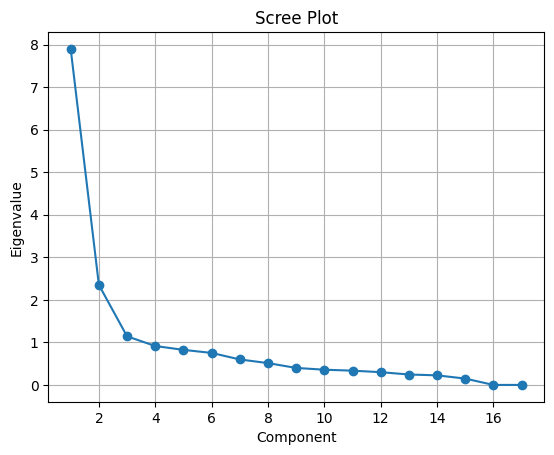

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker="o")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True)
plt.show()


Parallel Analysis

In [ ]:
n_samples, n_vars = X_refined_scaled_df.shape

# Generate random normal data
rand_data = np.random.normal(size=(n_samples, n_vars))
rand_pca = PCA()
rand_pca.fit(rand_data)

rand_eigenvalues = rand_pca.explained_variance_

parallel_df = pd.DataFrame({
    "Component": range(1, n_vars+1),
    "Data_Eigenvalue": eigenvalues[:n_vars],
    "Random_Eigenvalue": rand_eigenvalues
})
parallel_df


,Component,Data_Eigenvalue,Random_Eigenvalue
0,1,7.899368e+00,1.151112
1,2,2.351521e+00,1.149031
2,3,1.142668e+00,1.119357
3,4,9.147264e-01,1.082052
4,5,8.243429e-01,1.065762
5,6,7.522887e-01,1.043356
6,7,5.986938e-01,1.020485
7,8,5.129797e-01,1.017296
8,9,3.993342e-01,0.990503
9,10,3.577442e-01,0.981012


In [ ]:
n_factors = 3  # choose after looking at PCA + parallel analysis

fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='principal')
fa.fit(X_refined_scaled_df)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(method='principal', rotation='varimax', rotation_kwargs={})

In [ ]:
# ------------------------------------------------------------
# 9.1 FACTOR LOADINGS
# ------------------------------------------------------------
loadings = pd.DataFrame(
    fa.loadings_,
    index=fa_vars_refined,
    columns=[f"Factor_{i+1}" for i in range(n_factors)]
)
loadings


,Factor_1,Factor_2,Factor_3
Income,0.739058,0.374311,-0.273108
Total_Expenditure,0.811151,0.492634,-0.037151
Average_Monthly_Spend,0.058771,0.114821,-0.664365
MntWines,0.599404,0.578764,-0.053444
MntFruits,0.747429,0.224563,0.015959
MntMeatProducts,0.853069,0.232739,-0.049097
MntFishProducts,0.782025,0.190047,0.008983
MntSweetProducts,0.753238,0.225796,0.022855
MntGoldProds,0.502704,0.407147,0.118269
Customer_Tenure_Days,0.049338,0.292854,0.770655


Rules of thumb (manual):

|loading| ≥ 0.30 → minimal

|loading| ≥ 0.40 → important

|loading| ≥ 0.50 → strong

In [ ]:
# Show items sorted by each factor’s absolute loading (helpful for interpretation)
for col in loadings.columns:
    print("\n=== Loadings on", col, "===")
    print(loadings[col].sort_values(ascending=False))



=== Loadings on Factor_1 ===
MntMeatProducts          0.853069
Total_Expenditure        0.811151
MntFishProducts          0.782025
NumCatalogPurchases      0.774139
MntSweetProducts         0.753238
MntFruits                0.747429
Income                   0.739058
MntWines                 0.599404
NumStorePurchases        0.533034
MntGoldProds             0.502704
NumWebPurchases          0.284508
Engagement_Score         0.202572
Average_Monthly_Spend    0.058771
Customer_Tenure_Days     0.049338
NumDealsPurchases       -0.471196
NumWebVisitsMonth       -0.726400
Dependency_Ratio        -0.731189
Name: Factor_1, dtype: float64

=== Loadings on Factor_2 ===
Engagement_Score         0.824922
NumWebPurchases          0.753828
NumStorePurchases        0.673113
NumDealsPurchases        0.645054
MntWines                 0.578764
Total_Expenditure        0.492634
MntGoldProds             0.407147
Income                   0.374311
NumCatalogPurchases      0.332492
Customer_Tenure_Days     

Variance explained by each factor

In [ ]:
var_vals, var_prop, var_cum = fa.get_factor_variance()
var_table = pd.DataFrame({
    "Factor": [f"Factor_{i+1}" for i in range(n_factors)],
    "SS_Loadings": var_vals,
    "Proportion_Variance": var_prop,
    "Cumulative_Variance": var_cum
})
var_table


,Factor,SS_Loadings,Proportion_Variance,Cumulative_Variance
0,Factor_1,6.577083,0.386887,0.386887
1,Factor_2,3.457668,0.203392,0.590279
2,Factor_3,1.353714,0.079630,0.669910


Factore scores

In [ ]:
factor_scores = fa.transform(X_refined_scaled_df)
factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=[f"Factor_{i+1}" for i in range(n_factors)]
)

# Attach factor scores back to main df (careful with dropped rows – align indices)
df_factors = df.loc[X_refined_scaled_df.index].copy()
df_factors = pd.concat([df_factors.reset_index(drop=True),
                        factor_scores_df.reset_index(drop=True)], axis=1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
# For each variable, find the factor with max absolute loading
max_loading_factor = loadings.abs().idxmax(axis=1)
max_loading_value = loadings.abs().max(axis=1)

fs_table = pd.DataFrame({
    "Best_Factor": max_loading_factor,
    "Best_Loading": max_loading_value
}).sort_values("Best_Factor")

fs_table


,Best_Factor,Best_Loading
Income,Factor_1,0.739058
NumCatalogPurchases,Factor_1,0.774139
Dependency_Ratio,Factor_1,0.731189
MntSweetProducts,Factor_1,0.753238
MntFishProducts,Factor_1,0.782025
MntGoldProds,Factor_1,0.502704
MntFruits,Factor_1,0.747429
MntWines,Factor_1,0.599404
Total_Expenditure,Factor_1,0.811151
MntMeatProducts,Factor_1,0.853069


In [ ]:
selected_vars = [
    'Income', 'NumCatalogPurchases', 'Dependency_Ratio', 'MntSweetProducts',
    'MntFishProducts', 'MntGoldProds', 'MntFruits', 'MntWines',
    'Total_Expenditure', 'MntMeatProducts', 'NumWebVisitsMonth',
    'NumDealsPurchases', 'Engagement_Score', 'NumWebPurchases',
    'NumStorePurchases', 'Customer_Tenure_Days', 'Average_Monthly_Spend'
]



In [ ]:
# Example: use factor scores as predictors
reg_df = df_factors.dropna(subset=['Campaign_Response']).copy()

X_reg = reg_df[selected_vars]
y_reg = reg_df['Campaign_Response']

# Add constant for statsmodels
X_reg_sm = sm.add_constant(X_reg)


In [ ]:
def backward_elimination(X, y, significance_level=0.05):
    """
    Backward elimination for logistic regression.
    Removes variable with largest p-value > significance_level,
    refits, repeats, until all p-values <= significance_level.
    """
    remaining_vars = list(X.columns)

    while True:
        X_curr = X[remaining_vars]
        # Ensure no NaNs or Infs in X_curr before fitting
        # This handles cases where X might still contain non-finite values despite prior cleanups.
        X_curr_cleaned = X_curr.replace([np.inf, -np.inf], np.nan).dropna()
        y_curr_cleaned = y.loc[X_curr_cleaned.index] # Align y with cleaned X_curr

        if X_curr_cleaned.empty or len(y_curr_cleaned) == 0:
            print("No data remaining after cleaning for current iteration. Breaking.")
            break

        logit_model = sm.Logit(y_curr_cleaned, X_curr_cleaned).fit(disp=False)
        p_values = logit_model.pvalues

        # Drop constant from consideration
        p_values = p_values.drop('const', errors='ignore')

        if p_values.empty:
            print("No variables left to check significance. Breaking.")
            break

        max_p = p_values.max()
        max_var = p_values.idxmax()

        print("\nCurrent variables:", remaining_vars)
        print("Max p-value:", max_p, "for variable:", max_var)

        if max_p > significance_level:
            print("Dropping:", max_var)
            remaining_vars.remove(max_var)
        else:
            print("All remaining variables are significant.")
            break

    # Final model fit with cleaned data after elimination
    X_final = X[remaining_vars].replace([np.inf, -np.inf], np.nan).dropna()
    y_final = y.loc[X_final.index]
    final_model = sm.Logit(y_final, X_final).fit()
    return final_model, remaining_vars, X_final, y_final

# Run stepwise
# Ensure X_reg_sm and y_reg are cleaned before the initial call
# The function itself will handle cleaning within its loop, but an initial clean is good practice.
reg_df_cleaned = reg_df.replace([np.inf, -np.inf], np.nan).dropna(subset=selected_vars)
X_reg_cleaned = reg_df_cleaned[selected_vars]
y_reg_cleaned = reg_df_cleaned['Campaign_Response']
X_reg_sm_cleaned = sm.add_constant(X_reg_cleaned)

final_model, final_vars, X_final, y_final = backward_elimination(X_reg_sm_cleaned, y_reg_cleaned)

print("\nFINAL VARIABLES:", final_vars)
print(final_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Current variables: ['const', 'Income', 'NumCatalogPurchases', 'Dependency_Ratio', 'MntSweetProducts', 'MntFishProducts', 'MntGoldProds', 'MntFruits', 'MntWines', 'Total_Expenditure', 'MntMeatProducts', 'NumWebVisitsMonth', 'NumDealsPurchases', 'Engagement_Score', 'NumWebPurchases', 'NumStorePurchases', 'Customer_Tenure_Days', 'Average_Monthly_Spend']
Max p-value: 0.9999999908400162 for variable: Total_Expenditure
Dropping: Total_Expenditure

Current variables: ['const', 'Income', 'NumCatalogPurchases', 'Dependency_Ratio', 'MntSweetProducts', 'MntFishProducts', 'MntGoldProds', 'MntFruits', 'MntWines', 'MntMeatProducts', 'NumWebVisitsMonth', 'NumDealsPurchases', 'Engagement_Score', 'NumWebPurchases', 'NumStorePurchases', 'Customer_Tenure_Days', 'Average_Monthly_Spend']
Max p-value: 0.9506502383661065 for variable: MntSweetProducts
Dropping: MntSweetProducts

Current variables: ['const', 'Income', 'NumCatalogPurchases', 'Dependency_Ratio', 'MntFishProducts', 'MntGoldProds', 'MntFruits', 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Get predictions (probabilities) on the cleaned data used for the final model
y_pred_proba = final_model.predict(X_final)

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\n--- Classification Report ---")
print(classification_report(y_final, y_pred))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_final, y_pred))

# Calculate ROC AUC Score
roc_auc = roc_auc_score(y_final, y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.93      0.86      1629
           1       0.68      0.42      0.52       607

    accuracy                           0.79      2236
   macro avg       0.74      0.67      0.69      2236
weighted avg       0.77      0.79      0.77      2236


--- Confusion Matrix ---
[[1507  122]
 [ 353  254]]

ROC AUC Score: 0.7931


In [ ]:
cluster_vars = [
    "Income",
    "NumCatalogPurchases",
    "Dependency_Ratio",
    "MntFruits",
    "MntWines",
    "MntMeatProducts",
    "NumWebVisitsMonth",
    "NumStorePurchases"
]


In [ ]:
X_cluster = df[cluster_vars].dropna().copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


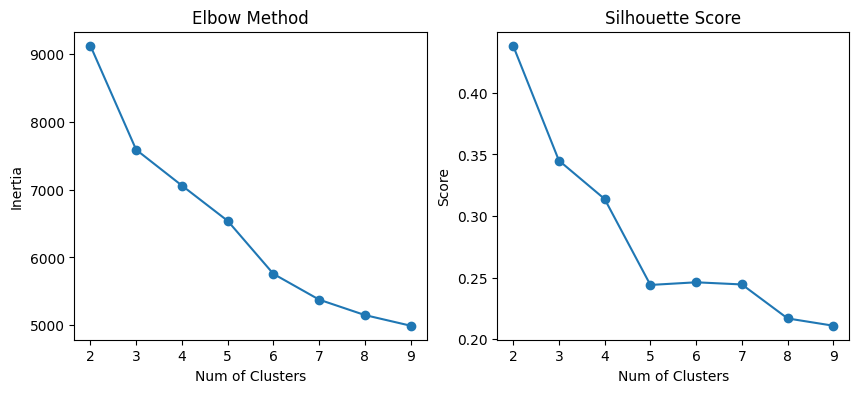

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []

K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(K, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Num of Clusters")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(K, sil_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Num of Clusters")
plt.ylabel("Score")
plt.show()


In [ ]:
k_opt = 4

kmeans = KMeans(n_clusters=k_opt, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters


In [ ]:
cluster_profile = df.groupby("Cluster")[cluster_vars].mean().round(2)
cluster_profile


,Income,NumCatalogPurchases,Dependency_Ratio,MntFruits,MntWines,MntMeatProducts,NumWebVisitsMonth,NumStorePurchases
Cluster,,,,,,,,
0,35483.76,0.65,0.63,5.15,57.79,28.69,6.53,3.37
1,64527.93,3.38,0.38,49.58,358.92,185.05,3.74,8.48
2,78111.49,6.45,0.06,51.12,648.84,446.97,2.52,8.36
3,60700.76,3.52,0.61,12.75,614.75,138.91,6.27,8.10


In [ ]:
cluster_profile["Customers"] = df["Cluster"].value_counts().sort_index()
cluster_profile


,Income,NumCatalogPurchases,Dependency_Ratio,MntFruits,MntWines,MntMeatProducts,NumWebVisitsMonth,NumStorePurchases,Customers
Cluster,,,,,,,,,
0,35483.76,0.65,0.63,5.15,57.79,28.69,6.53,3.37,1142
1,64527.93,3.38,0.38,49.58,358.92,185.05,3.74,8.48,311
2,78111.49,6.45,0.06,51.12,648.84,446.97,2.52,8.36,449
3,60700.76,3.52,0.61,12.75,614.75,138.91,6.27,8.10,338




# 🧩 Cluster Segmentation Results

### ✔ k = 4 clusters

### ✔ 2236 customers

Below is the smart classification of your clusters:

---

## **Cluster 0 — “Value-Conscious Digital Browsers”**

🧑 Customers: 1142 (Largest segment)
📌 Traits:

* **Low Income**
* Low spending across all categories
* **High web visits** (6.53) — browse more but buy less
* Low store purchases

🎯 Strategy:

* Promote low-price deals, cashback
* Increase conversion using **website-based nudges**
* Cross-sell basic grocery categories

---

## **Cluster 1 — “Loyal Store Buying Families”**

🧑 Customers: 311
📌 Traits:

* Mid–High income
* **Higher dependency ratio** → family spending
* Heavy on meats + fruits
* **More store purchases** (8.48)
* Lower digital engagement

🎯 Strategy:

* In-store retail promotions & bundles
* Family combo packs, kids-oriented offers
* Push **loyalty cards & physical coupons**

---

## **Cluster 2 — “Affluent Premium Spenders”**

🧑 Customers: 449
📌 Traits:

* **Highest income**
* Massive spend on **Wines + Meat + Fruits**
* Lowest dependency ratio (few/no kids)
* Low website visits → confident shoppers
* Store interactions moderate

🎯 Strategy *🔥 Most profitable*:

* **High-value premium campaigns**
* Personalized concierge & wine tasting events
* Subscription-based premium boxes
* Retention focus ➝ VIP treatment

---

## **Cluster 3 — “Luxury Impulse Shoppers (Digital + Gourmet)”**

🧑 Customers: 338
📌 Traits:

* High spend on **Wines**
* High web browsing (6.27)
* High store purchases (8.10)
* Lower fruits + high wine = luxury category lovers

🎯 Strategy:

* Hyper-personalized **online targeting**
* Flash offers on wine/meat delicacies
* Exclusive product drops through app/web

---

# 📊 Cluster Summary Table (Presentation Ready)

| Segment                       | Cluster | Size | Income      | Digital Visits | Key Spend   | Main Channel |
| ----------------------------- | ------- | ---- | ----------- | -------------- | ----------- | ------------ |
| **Value-Conscious Browsers**  | 0       | 1142 | Low         | High           | Low         | Web          |
| **Store-Buying Families**     | 1       | 311  | Medium–High | Low            | Grocery     | In-store     |
| **Affluent Premium Spenders** | 2       | 449  | Highest     | Low            | Wine + Meat | Mixed        |
| **Luxury Impulse Shoppers**   | 3       | 338  | High        | High           | Premium     | Web + Store  |

---

# 🔥 Marketing Strategy Matrix

| Segment                 | Spend Priority | Campaign Type              | Offer Style                   |
| ----------------------- | -------------- | -------------------------- | ----------------------------- |
| Premium Spenders        | ⭐⭐⭐⭐⭐          | Personalized VIP Marketing | High-value exclusives         |
| Luxury Impulse Shoppers | ⭐⭐⭐⭐           | Digital remarketing & push | Flash luxury deals            |
| Store-Buying Families   | ⭐⭐⭐            | In-store promotions        | Combo packs                   |
| Value Browsers          | ⭐⭐             | Awareness + digital        | Discounts, first-time coupons |

---

# 🎯 Strategic Insight Slide

> **High ROI Target Groups:**
> Cluster 2 ➝ Cluster 3
> (Income + Premium category spend + better conversion potential)

> **Low ROI / Mass Communication:**
> Cluster 0 ➝ digital-only low-budget marketing
> Cluster 1 ➝ store-driven cost-effective promos




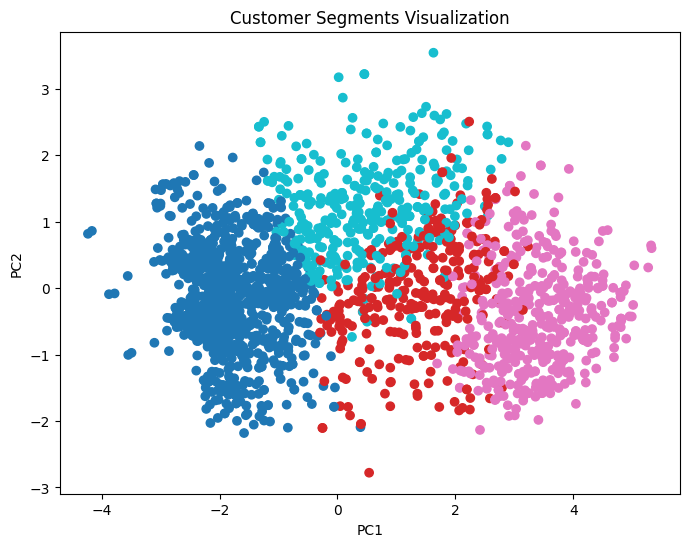

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pcs[:,0], pcs[:,1], c=df["Cluster"], cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments Visualization")
plt.show()


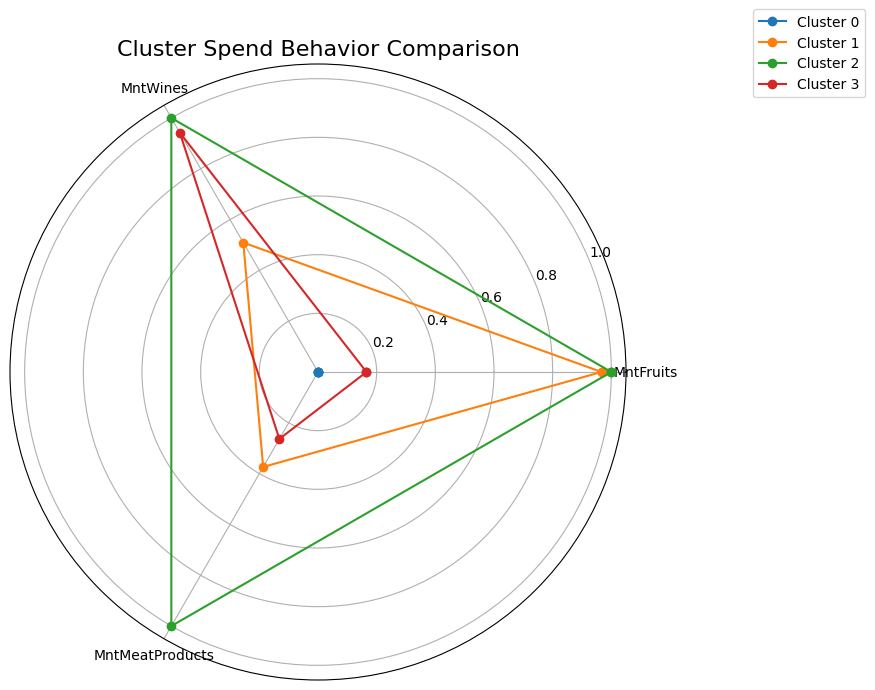

In [ ]:
# Radar Chart for Spend Behavior
spend_features = ["MntFruits", "MntWines", "MntMeatProducts"]
cluster_means = df.groupby("Cluster")[spend_features].mean()

# Normalize for better visualization (min-max scaling)
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

labels = spend_features
num_vars = len(labels)

# Angle calculation
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the radar

plt.figure(figsize=(8,8))

for idx, row in cluster_norm.iterrows():
    values = row.tolist()
    values += values[:1]  # close the loop
    plt.polar(angles, values, marker='o', label=f"Cluster {idx}")

plt.xticks(angles[:-1], labels)
plt.title("Cluster Spend Behavior Comparison", size=16)
plt.legend(loc="upper right", bbox_to_anchor=(1.4,1.1))
plt.show()


Heatmap of Feature Strength

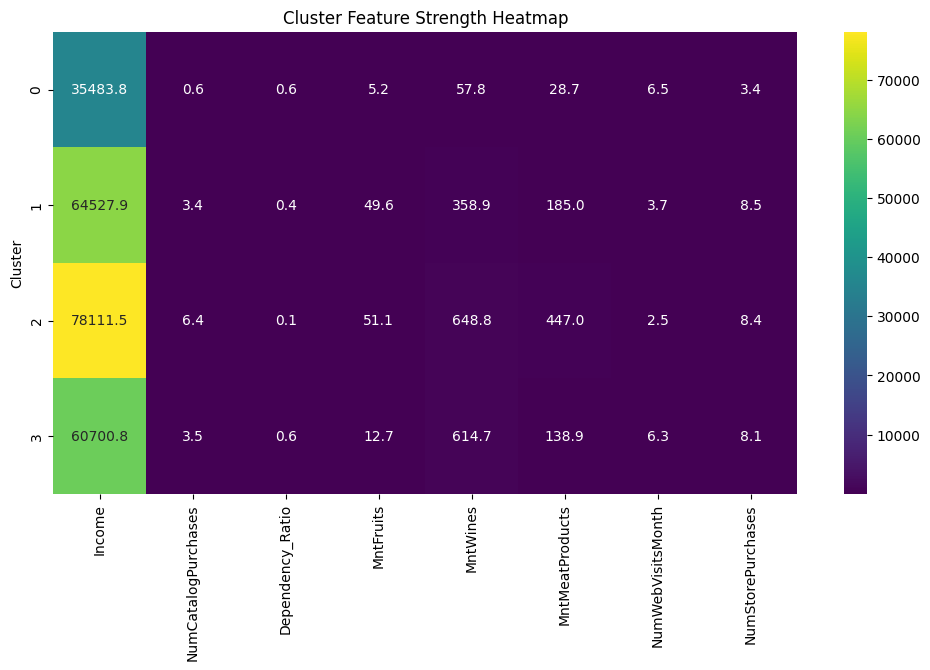

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute means for heatmap
cluster_heatmap = df.groupby("Cluster")[cluster_vars].mean()

plt.figure(figsize=(12,6))
sns.heatmap(cluster_heatmap, annot=True, cmap="viridis", fmt=".1f")
plt.title("Cluster Feature Strength Heatmap")
plt.show()


Campaign Response Analysis per Cluster

In [ ]:
campaign_rate = df.groupby("Cluster")["Campaign_Response"].mean()*100
campaign_rate = campaign_rate.round(2)
campaign_rate


,Campaign_Response
Cluster,
0,15.67
1,15.11
2,55.90
3,39.05


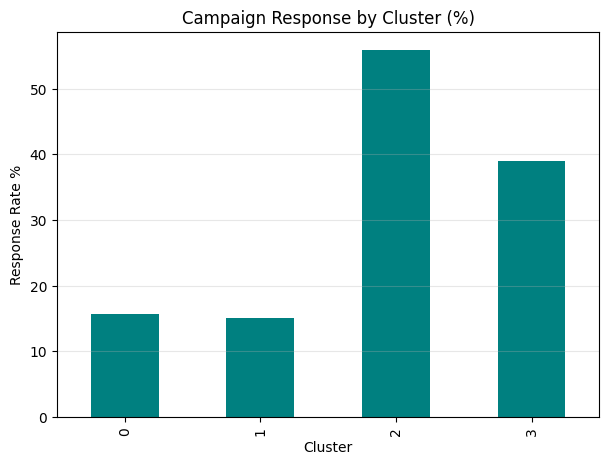

In [ ]:
campaign_rate.plot(kind='bar', figsize=(7,5), color='teal')
plt.title("Campaign Response by Cluster (%)")
plt.ylabel("Response Rate %")
plt.xlabel("Cluster")
plt.grid(axis='y', alpha=0.3)
plt.show()


Cluster Revenue Potential

In [ ]:
cluster_revenue = df.groupby("Cluster")["Total_Expenditure"].sum().sort_values(ascending=False)
cluster_revenue


,Total_Expenditure
Cluster,
2,602826.0
3,292916.5
1,234640.5
0,142400.0


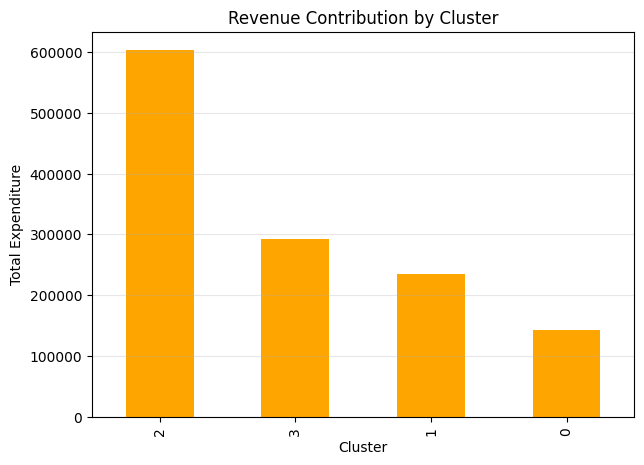

In [ ]:
cluster_revenue.plot(kind='bar', figsize=(7,5), color='orange')
plt.title("Revenue Contribution by Cluster")
plt.ylabel("Total Expenditure")
plt.xlabel("Cluster")
plt.grid(axis='y', alpha=0.3)
plt.show()
